In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import folium
from folium.plugins import HeatMap, MarkerCluster
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. Load Data Gempa Bumi

In [2]:
# Load dataset
df = pd.read_csv('../../Data/earthquake_dataset.csv')

print(f"Jumlah data: {len(df)} gempa bumi")
print(f"\nKolom dataset:")
print(df.columns.tolist())

df.head(10)

Jumlah data: 16944 gempa bumi

Kolom dataset:
['Date', 'Time (UTC)', 'City', 'Country', 'Latitude', 'Longitude', 'Earthquake Magnitude', 'Depth (km)', 'Impact Score']


,Date,Time (UTC),City,Country,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
0,2025-03-15,16:28:36,55 km NNW of Finschhafen,Papua New Guinea,-6.1233,147.5932,5.1,59.033,400
1,2025-03-15,03:19:27,5 km ESE of San Miguel Achiutla,Mexico,17.2871,-97.4400,5.6,63.551,503
2,2025-03-14,23:42:35,South Sandwich Islands region,South Sandwich Islands region,-55.7385,-27.1122,6.0,35.379,554
3,2025-03-14,19:37:15,15 km NNE of Lesina,Italy,41.9788,15.4490,5.0,8.742,389
4,2025-03-14,11:13:32,229 km N of Palu,Indonesia,1.1364,120.2317,5.4,26.072,449
5,2025-03-13,22:04:45,89 km NNE of Ambler,Alaska,67.8308,-157.0621,5.1,9.800,400
6,2025-03-13,21:20:11,51 km SSW of Padam,India,33.0777,76.5809,5.1,56.996,431
7,2025-03-13,15:45:41,138 km NE of Lospalos,Timor Leste,-7.5648,127.8120,5.0,158.207,385
8,2025-03-13,05:09:40,96 km S of Hualien City,Taiwan,23.1142,121.4919,5.2,27.312,420
9,2025-03-12,17:29:50,56 km WSW of Point Hope,Alaska,68.2130,-168.0594,5.0,38.500,385


In [3]:
# Info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16944 entries, 0 to 16943
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  16944 non-null  object 
 1   Time (UTC)            16944 non-null  object 
 2   City                  16944 non-null  object 
 3   Country               16944 non-null  object 
 4   Latitude              16944 non-null  float64
 5   Longitude             16944 non-null  float64
 6   Earthquake Magnitude  16944 non-null  float64
 7   Depth (km)            16944 non-null  float64
 8   Impact Score          16944 non-null  int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 1.2+ MB


## 3. Data Cleaning (Pembersihan Data)

In [4]:
# Cek missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Cek duplikat
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Statistik deskriptif
print("\nStatistik Magnitude:")
print(df['Earthquake Magnitude'].describe())

Missing Values:
Date                    0
Time (UTC)              0
City                    0
Country                 0
Latitude                0
Longitude               0
Earthquake Magnitude    0
Depth (km)              0
Impact Score            0
dtype: int64

Total missing values: 0

Duplicate rows: 0

Statistik Magnitude:
count    16944.000000
mean         5.333485
std          0.404258
min          5.000000
25%          5.100000
50%          5.200000
75%          5.500000
max          8.300000
Name: Earthquake Magnitude, dtype: float64


In [5]:
# Hapus data dengan koordinat yang hilang
df_clean = df.dropna(subset=['Latitude', 'Longitude'])

print(f"Data setelah pembersihan: {len(df_clean)} gempa bumi")
print(f"Data yang dihapus: {len(df) - len(df_clean)} gempa bumi")

# Reset index
df_clean = df_clean.reset_index(drop=True)
df_clean.head()

Data setelah pembersihan: 16944 gempa bumi
Data yang dihapus: 0 gempa bumi


,Date,Time (UTC),City,Country,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
0,2025-03-15,16:28:36,55 km NNW of Finschhafen,Papua New Guinea,-6.1233,147.5932,5.1,59.033,400
1,2025-03-15,03:19:27,5 km ESE of San Miguel Achiutla,Mexico,17.2871,-97.4400,5.6,63.551,503
2,2025-03-14,23:42:35,South Sandwich Islands region,South Sandwich Islands region,-55.7385,-27.1122,6.0,35.379,554
3,2025-03-14,19:37:15,15 km NNE of Lesina,Italy,41.9788,15.4490,5.0,8.742,389
4,2025-03-14,11:13:32,229 km N of Palu,Indonesia,1.1364,120.2317,5.4,26.072,449


## 4. Exploratory Data Analysis (EDA)

### 4.1. Distribusi Gempa per Negara

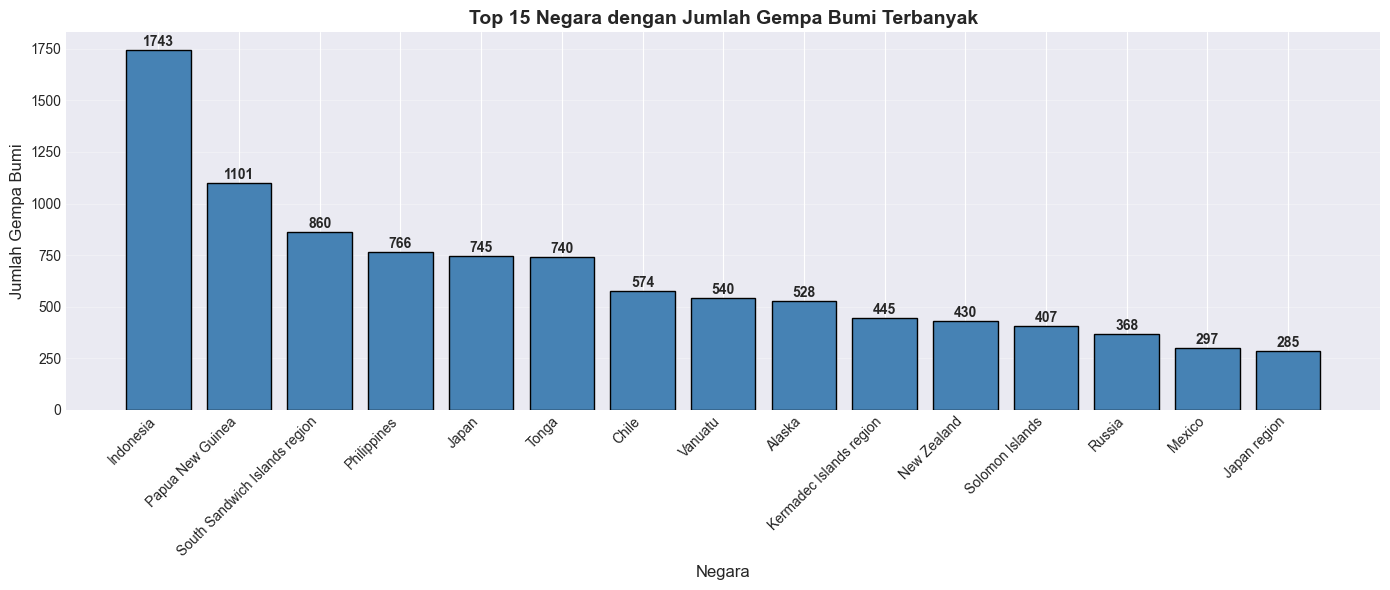


Total negara: 322


In [6]:
# Hitung jumlah gempa per negara
gempa_per_negara = df_clean['Country'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(gempa_per_negara)), gempa_per_negara.values, color='steelblue', edgecolor='black')
plt.xlabel('Negara', fontsize=12)
plt.ylabel('Jumlah Gempa Bumi', fontsize=12)
plt.title('Top 15 Negara dengan Jumlah Gempa Bumi Terbanyak', fontsize=14, fontweight='bold')
plt.xticks(range(len(gempa_per_negara)), gempa_per_negara.index, rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(gempa_per_negara.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal negara: {df_clean['Country'].nunique()}")

### 4.2. Konversi ke GeoDataFrame

In [7]:
# Buat geometry dari koordinat
geometry = [Point(xy) for xy in zip(df_clean['Longitude'], df_clean['Latitude'])]

# Buat GeoDataFrame
gdf = gpd.GeoDataFrame(df_clean, geometry=geometry, crs='EPSG:4326')

print("GeoDataFrame berhasil dibuat!")
print(f"CRS: {gdf.crs}")
print(f"\nBounds:")
print(gdf.total_bounds)

gdf.head()

GeoDataFrame berhasil dibuat!
CRS: EPSG:4326

Bounds:
[-179.9897  -69.7739  179.9981   87.386 ]


,Date,Time (UTC),City,Country,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score,geometry
0,2025-03-15,16:28:36,55 km NNW of Finschhafen,Papua New Guinea,-6.1233,147.5932,5.1,59.033,400,POINT (147.5932 -6.1233)
1,2025-03-15,03:19:27,5 km ESE of San Miguel Achiutla,Mexico,17.2871,-97.4400,5.6,63.551,503,POINT (-97.44 17.2871)
2,2025-03-14,23:42:35,South Sandwich Islands region,South Sandwich Islands region,-55.7385,-27.1122,6.0,35.379,554,POINT (-27.1122 -55.7385)
3,2025-03-14,19:37:15,15 km NNE of Lesina,Italy,41.9788,15.4490,5.0,8.742,389,POINT (15.449 41.9788)
4,2025-03-14,11:13:32,229 km N of Palu,Indonesia,1.1364,120.2317,5.4,26.072,449,POINT (120.2317 1.1364)


### 4.3. Visualisasi Peta Sebaran Gempa dengan Basemap

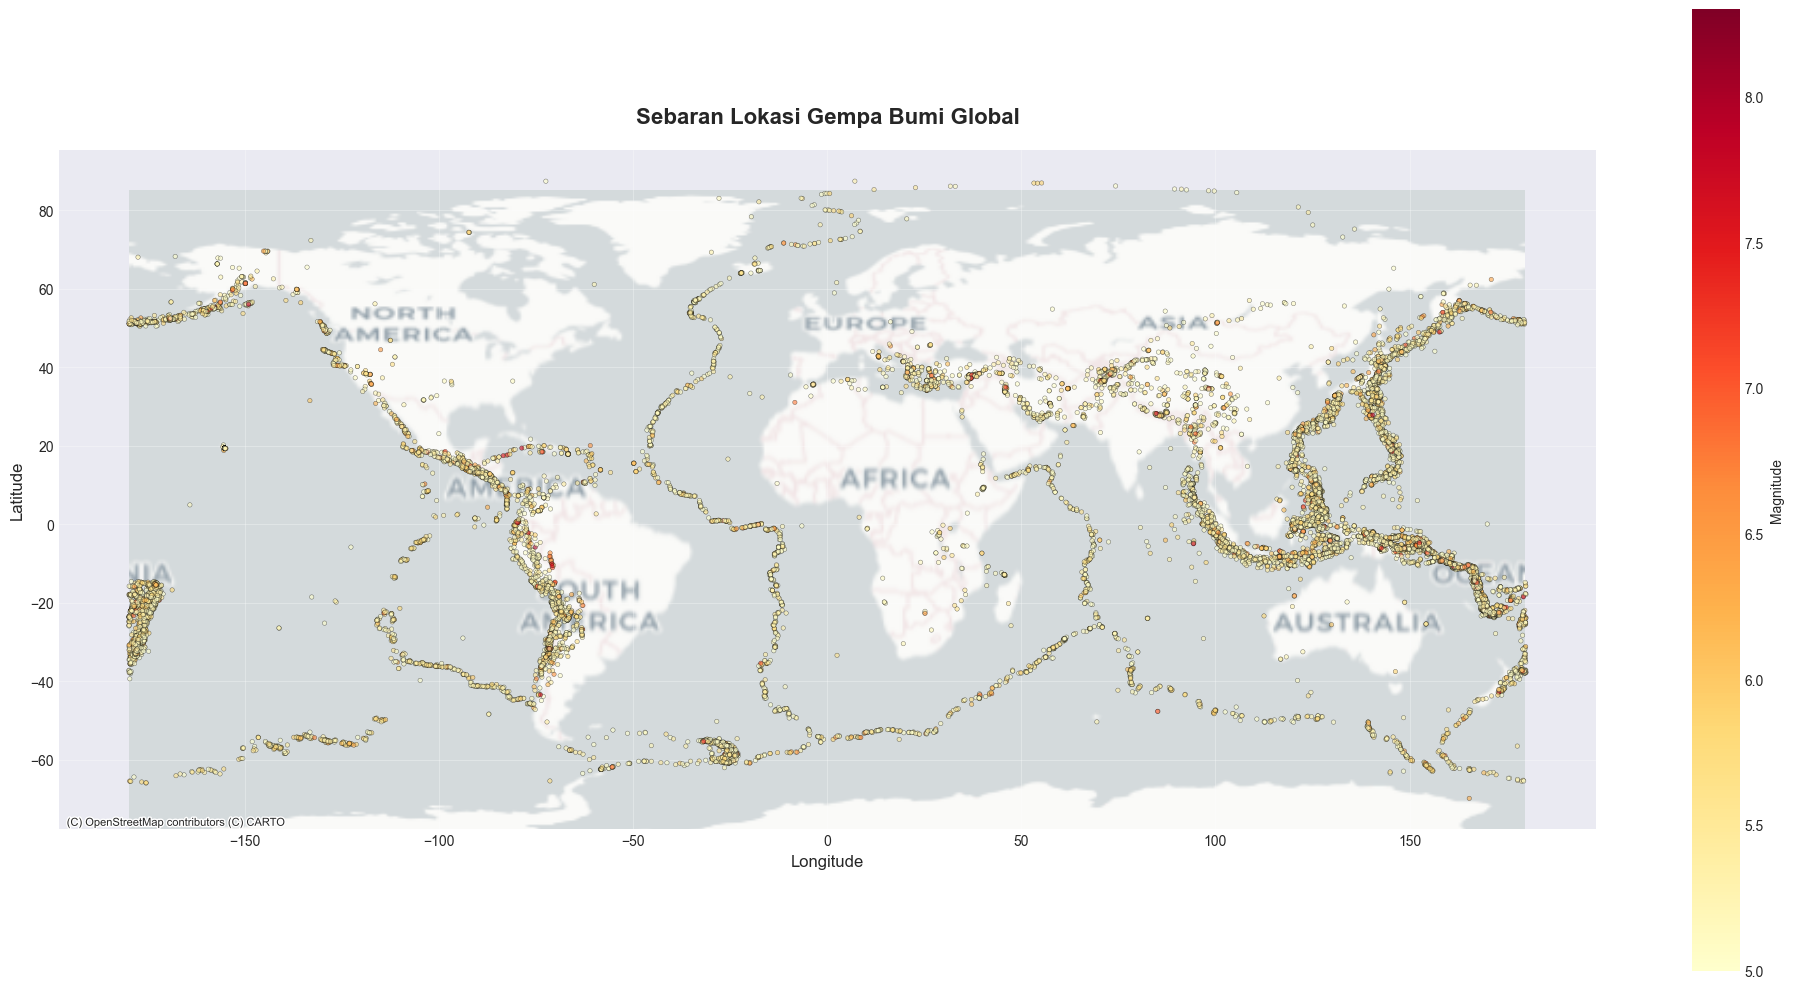

In [8]:
# Plot dengan basemap
fig, ax = plt.subplots(figsize=(20, 10))

# Plot points dengan warna berdasarkan magnitude
gdf.plot(ax=ax, column='Earthquake Magnitude', cmap='YlOrRd', markersize=10, 
         alpha=0.6, edgecolor='black', linewidth=0.3, legend=True,
         legend_kwds={'label': 'Magnitude', 'orientation': 'vertical'})

# Tambahkan basemap
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.CartoDB.Positron, zoom=1)

ax.set_title('Sebaran Lokasi Gempa Bumi Global', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4. Visualisasi Heatmap dengan Folium

In [9]:
# Hitung pusat peta
center_lat = df_clean['Latitude'].mean()
center_lon = df_clean['Longitude'].mean()

# Buat peta dasar
peta_gempa = folium.Map(location=[center_lat, center_lon], zoom_start=2, tiles='OpenStreetMap')

# Data untuk heatmap
heat_data = [[row['Latitude'], row['Longitude']] for idx, row in df_clean.iterrows()]

# Tambahkan heatmap
HeatMap(heat_data, radius=8, blur=15, max_zoom=13, 
        gradient={0.4: 'blue', 0.6: 'lime', 0.8: 'orange', 1: 'red'}).add_to(peta_gempa)

peta_gempa

### 4.5. Peta Interaktif dengan Marker (Sample 500 Data)

In [10]:
# Buat peta dengan marker cluster
peta_marker = folium.Map(location=[center_lat, center_lon], zoom_start=2, tiles='OpenStreetMap')
marker_cluster = MarkerCluster().add_to(peta_marker)

# Sample 500 data
sample_data = df_clean.sample(min(500, len(df_clean)), random_state=42)

for idx, row in sample_data.iterrows():
    popup_text = f"""<b>{row['City']}, {row['Country']}</b><br>
                     Magnitude: {row['Earthquake Magnitude']}<br>
                     Depth: {row['Depth (km)']} km<br>
                     Date: {row['Date']}"""
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(marker_cluster)

peta_marker

## 5. Preprocessing untuk DBSCAN

### 5.1. Ekstraksi Fitur Koordinat

In [11]:
# Ekstrak koordinat untuk clustering
coordinates = df_clean[['Latitude', 'Longitude']].values

print(f"Shape data koordinat: {coordinates.shape}")
print(f"\nSample koordinat (5 data pertama):")
print(coordinates[:5])

Shape data koordinat: (16944, 2)

Sample koordinat (5 data pertama):
[[ -6.1233 147.5932]
 [ 17.2871 -97.44  ]
 [-55.7385 -27.1122]
 [ 41.9788  15.449 ]
 [  1.1364 120.2317]]


### 5.2. Normalisasi Data Koordinat

In [12]:
# Normalisasi koordinat
scaler = StandardScaler()
coordinates_scaled = scaler.fit_transform(coordinates)

print("Data koordinat setelah normalisasi:")
print(f"Mean: {coordinates_scaled.mean(axis=0)}")
print(f"Std: {coordinates_scaled.std(axis=0)}")
print(f"\nSample data (5 pertama):")
print(coordinates_scaled[:5])

Data koordinat setelah normalisasi:
Mean: [ 2.43221664e-17 -2.34834710e-17]
Std: [1. 1.]

Sample data (5 pertama):
[[-0.09536581  0.93407493]
 [ 0.67018516 -1.04322986]
 [-1.71784833 -0.47571699]
 [ 1.47763634 -0.13226775]
 [ 0.14203596  0.71328026]]


## 6. Menentukan Parameter DBSCAN

### 6.1. K-Distance Graph untuk Menentukan Epsilon

Min samples yang disarankan: 4


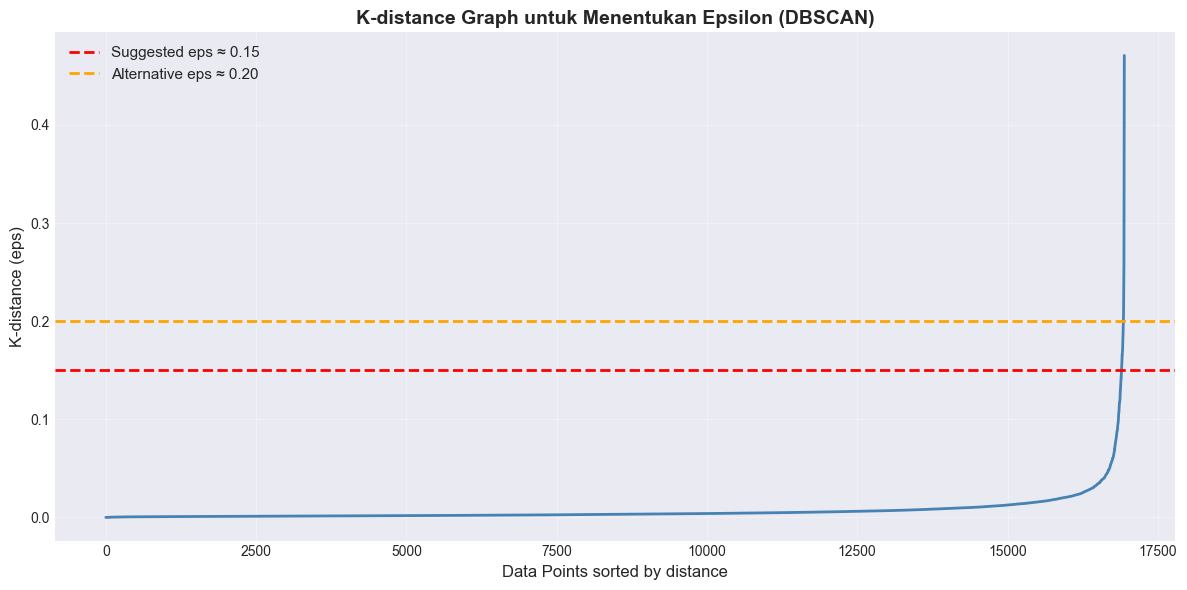


Berdasarkan grafik, eps yang disarankan sekitar 0.10 - 0.25


In [13]:
# Tentukan min_samples
min_samples = 2 * coordinates_scaled.shape[1]
print(f"Min samples yang disarankan: {min_samples}")

# Hitung jarak ke k-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(coordinates_scaled)
distances, indices = neighbors_fit.kneighbors(coordinates_scaled)

# Ambil jarak terjauh dan urutkan
distances = np.sort(distances[:, -1], axis=0)

# Plot K-distance graph
plt.figure(figsize=(12, 6))
plt.plot(distances, linewidth=2, color='steelblue')
plt.ylabel('K-distance (eps)', fontsize=12)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.title('K-distance Graph untuk Menentukan Epsilon (DBSCAN)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.axhline(y=0.15, color='r', linestyle='--', linewidth=2, label='Suggested eps ≈ 0.15')
plt.axhline(y=0.20, color='orange', linestyle='--', linewidth=2, label='Alternative eps ≈ 0.20')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nBerdasarkan grafik, eps yang disarankan sekitar 0.10 - 0.25")

## 7. Implementasi DBSCAN

In [14]:
# Terapkan DBSCAN
eps = 0.15
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
clusters = dbscan.fit_predict(coordinates_scaled)

# Tambahkan hasil clustering
df_clean['Cluster'] = clusters
gdf['Cluster'] = clusters

# Tampilkan hasil
print("="*70)
print("HASIL CLUSTERING DBSCAN")
print("="*70)
print(f"\nParameter DBSCAN:")
print(f"  - Epsilon (eps): {eps}")
print(f"  - Min samples: {min_samples}")

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"\nHasil Clustering:")
print(f"  - Jumlah cluster: {n_clusters}")
print(f"  - Jumlah noise points: {n_noise}")
print(f"  - Persentase noise: {(n_noise/len(clusters)*100):.2f}%")

print(f"\nDistribusi Gempa per Cluster:")
cluster_dist = pd.Series(clusters).value_counts().sort_index()
for cluster_id, count in cluster_dist.items():
    if cluster_id == -1:
        print(f"  Cluster {cluster_id} (Noise/Outlier): {count} gempa")
    else:
        print(f"  Cluster {cluster_id}: {count} gempa")
print("="*70)

HASIL CLUSTERING DBSCAN

Parameter DBSCAN:
  - Epsilon (eps): 0.15
  - Min samples: 5

Hasil Clustering:
  - Jumlah cluster: 6
  - Jumlah noise points: 37
  - Persentase noise: 0.22%

Distribusi Gempa per Cluster:
  Cluster -1 (Noise/Outlier): 37 gempa
  Cluster 0: 14115 gempa
  Cluster 1: 455 gempa
  Cluster 2: 2050 gempa
  Cluster 3: 214 gempa
  Cluster 4: 7 gempa
  Cluster 5: 66 gempa


## 8. Evaluasi Clustering

In [15]:
# Evaluasi clustering (tanpa noise points)
mask = clusters != -1
n_clusters_eval = len(set(clusters[mask]))

print(f"Jumlah cluster untuk evaluasi: {n_clusters_eval}")

if n_clusters_eval > 1 and mask.sum() > 0:
    silhouette = silhouette_score(coordinates_scaled[mask], clusters[mask])
    davies_bouldin = davies_bouldin_score(coordinates_scaled[mask], clusters[mask])
    calinski_harabasz = calinski_harabasz_score(coordinates_scaled[mask], clusters[mask])
    
    print("\n" + "="*70)
    print("METRIK EVALUASI CLUSTERING")
    print("="*70)
    print(f"\nSilhouette Score: {silhouette:.4f}")
    print(f"  → Range: -1 to 1 (semakin tinggi semakin baik)")
    print(f"  → Interpretasi: {'Baik' if silhouette > 0.5 else 'Cukup' if silhouette > 0.25 else 'Kurang baik'}")
    
    print(f"\nDavies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"  → Semakin rendah semakin baik")
    print(f"  → Interpretasi: {'Baik' if davies_bouldin < 1 else 'Cukup' if davies_bouldin < 2 else 'Kurang baik'}")
    
    print(f"\nCalinski-Harabasz Score: {calinski_harabasz:.4f}")
    print(f"  → Semakin tinggi semakin baik")
    print("="*70)
elif n_clusters_eval == 1:
    print("\n⚠️  Hanya 1 cluster, pertimbangkan menurunkan eps atau min_samples")
else:
    print("\n⚠️  Semua data adalah noise, pertimbangkan meningkatkan eps")

Jumlah cluster untuk evaluasi: 6

METRIK EVALUASI CLUSTERING

Silhouette Score: 0.2004
  → Range: -1 to 1 (semakin tinggi semakin baik)
  → Interpretasi: Kurang baik

Davies-Bouldin Index: 0.5250
  → Semakin rendah semakin baik
  → Interpretasi: Baik

Calinski-Harabasz Score: 1946.2092
  → Semakin tinggi semakin baik


## 9. Visualisasi Hasil Clustering

### 9.1. Peta Sebaran Gempa dengan Warna Cluster

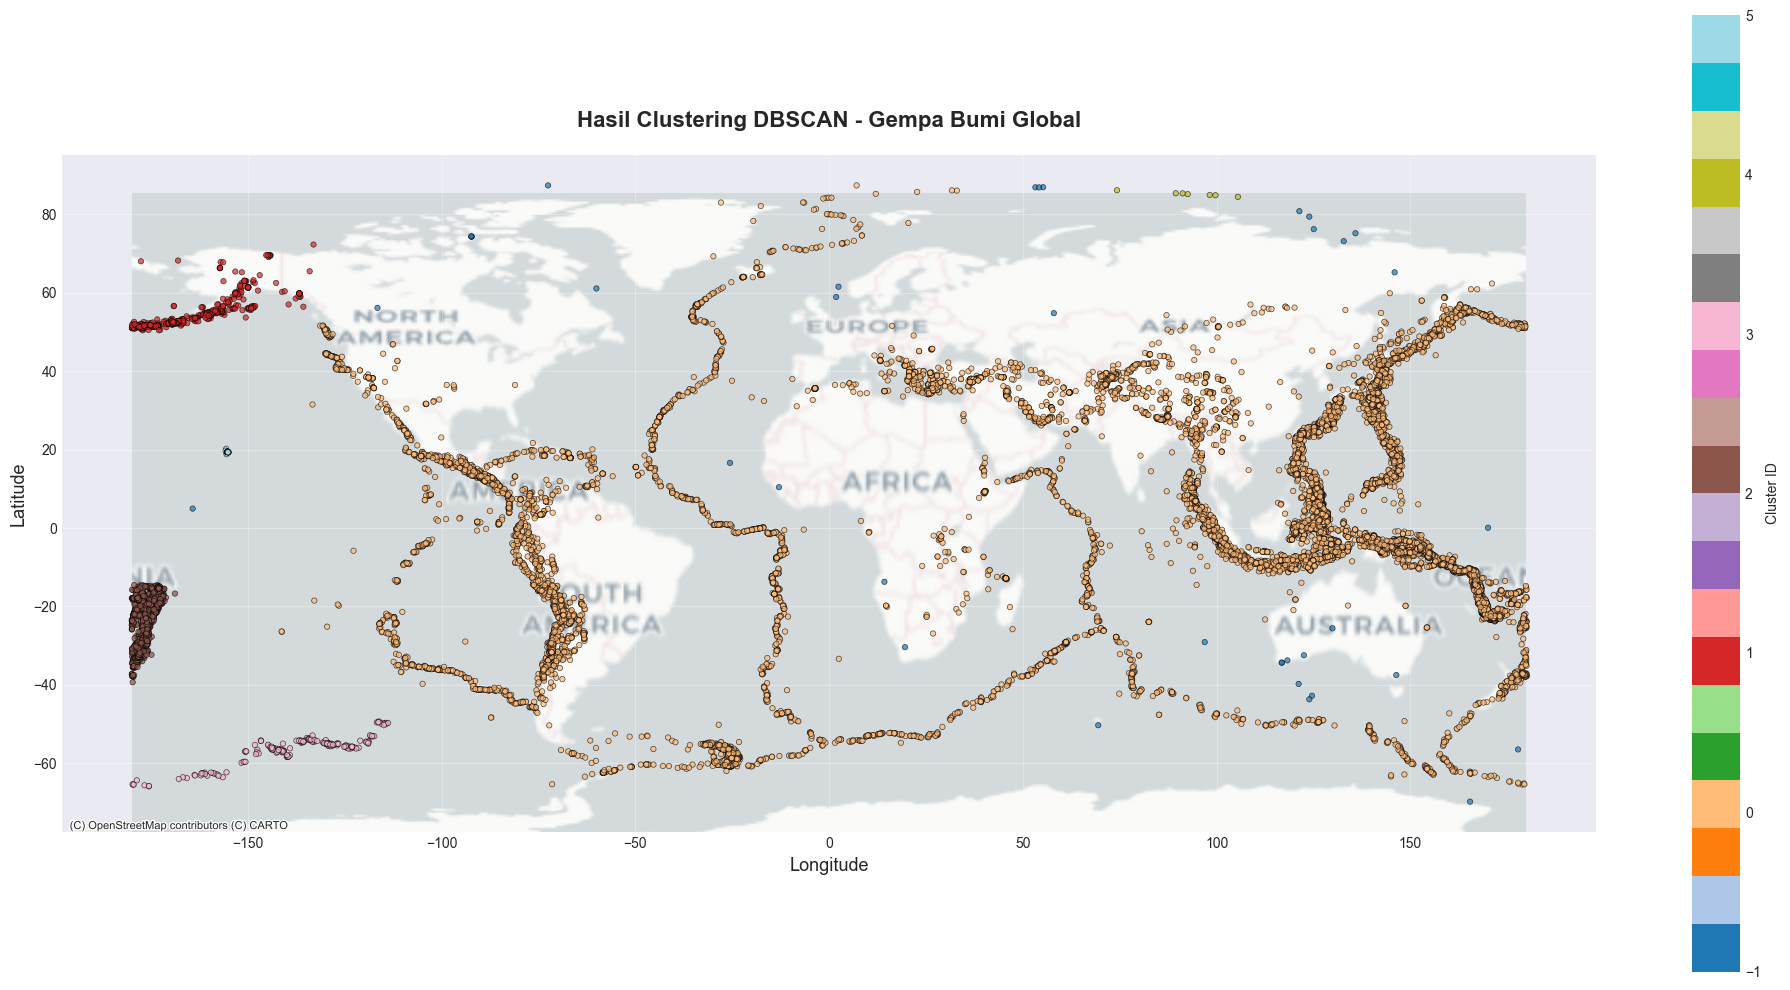

In [16]:
# Plot hasil clustering dengan basemap
fig, ax = plt.subplots(figsize=(20, 10))

# Plot berdasarkan cluster
gdf.plot(column='Cluster', ax=ax, cmap='tab20', markersize=15, 
         alpha=0.7, edgecolor='black', linewidth=0.5, legend=True,
         legend_kwds={'label': 'Cluster ID', 'orientation': 'vertical'})

# Tambahkan basemap
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.CartoDB.Positron, zoom=1)

ax.set_title('Hasil Clustering DBSCAN - Gempa Bumi Global', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.2. Peta Interaktif Hasil Clustering (Sample 500 Data)

In [17]:
# Buat peta interaktif dengan cluster
peta_cluster = folium.Map(location=[center_lat, center_lon], zoom_start=2)

# Warna untuk setiap cluster
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 
          'lightred', 'beige', 'darkblue', 'darkgreen', 'cadetblue', 
          'darkpurple', 'pink', 'lightblue', 'lightgreen', 'gray', 'black']

# Sample data
sample_cluster = df_clean.sample(min(500, len(df_clean)), random_state=42)

for idx, row in sample_cluster.iterrows():
    cluster_id = row['Cluster']
    
    if cluster_id == -1:
        color = 'gray'
        icon = 'remove-sign'
    else:
        color = colors[cluster_id % len(colors)]
        icon = 'info-sign'
    
    popup_text = f"""<b>{row['City']}, {row['Country']}</b><br>
                     <b>Cluster: {cluster_id}</b><br>
                     Magnitude: {row['Earthquake Magnitude']}<br>
                     Depth: {row['Depth (km)']} km<br>
                     Date: {row['Date']}"""
    
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_text, max_width=350),
        icon=folium.Icon(color=color, icon=icon),
        tooltip=f"Cluster {cluster_id}: {row['City']}"
    ).add_to(peta_cluster)

peta_cluster

### 9.3. Distribusi Cluster (Bar Chart)

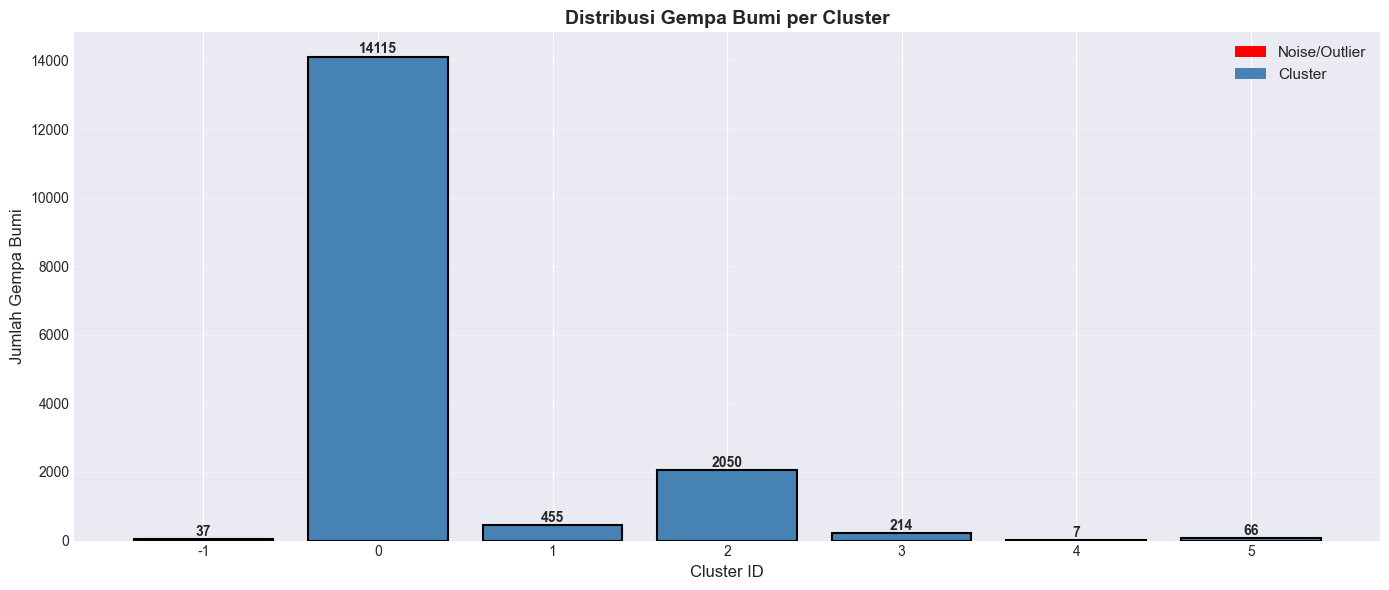

In [18]:
# Visualisasi distribusi cluster
cluster_counts = pd.Series(clusters).value_counts().sort_index()

plt.figure(figsize=(14, 6))
colors_bar = ['red' if idx == -1 else 'steelblue' for idx in cluster_counts.index]
bars = plt.bar(range(len(cluster_counts)), cluster_counts.values, color=colors_bar, edgecolor='black', linewidth=1.5)

plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Jumlah Gempa Bumi', fontsize=12)
plt.title('Distribusi Gempa Bumi per Cluster', fontsize=14, fontweight='bold')
plt.xticks(range(len(cluster_counts)), cluster_counts.index)
plt.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Noise/Outlier'),
                   Patch(facecolor='steelblue', label='Cluster')]
plt.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

## 10. Analisis Karakteristik Cluster

In [19]:
# Analisis setiap cluster
print("="*80)
print("ANALISIS KARAKTERISTIK SETIAP CLUSTER")
print("="*80)

for cluster_id in sorted(set(clusters)):
    cluster_data = df_clean[df_clean['Cluster'] == cluster_id]
    
    if cluster_id == -1:
        print(f"\n{'='*80}")
        print(f"CLUSTER {cluster_id} (NOISE/OUTLIER)")
        print(f"{'='*80}")
    else:
        print(f"\n{'='*80}")
        print(f"CLUSTER {cluster_id}")
        print(f"{'='*80}")
    
    print(f"\nJumlah Gempa: {len(cluster_data)}")
    
    # Statistik lokasi
    print(f"\nStatistik Koordinat:")
    print(f"  Latitude  - Min: {cluster_data['Latitude'].min():.4f}, Max: {cluster_data['Latitude'].max():.4f}, Mean: {cluster_data['Latitude'].mean():.4f}")
    print(f"  Longitude - Min: {cluster_data['Longitude'].min():.4f}, Max: {cluster_data['Longitude'].max():.4f}, Mean: {cluster_data['Longitude'].mean():.4f}")
    
    # Statistik gempa
    print(f"\nStatistik Gempa:")
    print(f"  Magnitude - Min: {cluster_data['Earthquake Magnitude'].min():.2f}, Max: {cluster_data['Earthquake Magnitude'].max():.2f}, Mean: {cluster_data['Earthquake Magnitude'].mean():.2f}")
    print(f"  Depth - Min: {cluster_data['Depth (km)'].min():.2f} km, Max: {cluster_data['Depth (km)'].max():.2f} km, Mean: {cluster_data['Depth (km)'].mean():.2f} km")
    
    # Distribusi per negara
    print(f"\nDistribusi per Negara (Top 5):")
    negara_dist = cluster_data['Country'].value_counts().head(5)
    for negara, count in negara_dist.items():
        print(f"  {negara}: {count} gempa")
    
    # Sample gempa
    print(f"\nContoh Gempa dalam Cluster:")
    sample_gempa = cluster_data[['Date', 'City', 'Country', 'Earthquake Magnitude']].head(3)
    for idx, row in sample_gempa.iterrows():
        print(f"  - {row['Date']}: {row['City']}, {row['Country']} (M{row['Earthquake Magnitude']})")
    
    if len(cluster_data) > 3:
        print(f"  ... dan {len(cluster_data) - 3} gempa lainnya")

print(f"\n{'='*80}")

ANALISIS KARAKTERISTIK SETIAP CLUSTER

CLUSTER -1 (NOISE/OUTLIER)

Jumlah Gempa: 37

Statistik Koordinat:
  Latitude  - Min: -69.7739, Max: 87.3752, Mean: 20.8597
  Longitude - Min: -164.2797, Max: 177.7725, Mean: 57.1365

Statistik Gempa:
  Magnitude - Min: 5.00, Max: 6.30, Mean: 5.32
  Depth - Min: 0.00 km, Max: 31.00 km, Mean: 10.67 km

Distribusi per Negara (Top 5):
  Australia: 6 gempa
  Russia: 4 gempa
  Canada: 4 gempa
  north of Franz Josef Land: 3 gempa
  Norway: 2 gempa

Contoh Gempa dalam Cluster:
  - 2025-02-28: 209 km NE of Tiksi, Russia (M5.0)
  - 2025-02-08: 146 km ENE of Ust-Nera, Russia (M5.0)
  - 2024-12-22: 89 km W of Brandvlei, South Africa (M5.2)
  ... dan 34 gempa lainnya

CLUSTER 0

Jumlah Gempa: 14115

Statistik Koordinat:
  Latitude  - Min: -65.4071, Max: 87.3860, Mean: -1.4366
  Longitude - Min: -141.3327, Max: 179.9981, Mean: 71.7489

Statistik Gempa:
  Magnitude - Min: 5.00, Max: 8.30, Mean: 5.33
  Depth - Min: 0.00 km, Max: 670.81 km, Mean: 47.12 km

Distri

## 11. Export Hasil Clustering

In [20]:
# Export ke CSV
output_file = '../../Model/hasil_clustering_earthquake.csv'
df_clean.to_csv(output_file, index=False)
print(f"✅ Hasil clustering telah disimpan ke: {output_file}")

# Export ke GeoJSON
output_geojson = '../../Model/hasil_clustering_earthquake.geojson'
gdf.to_file(output_geojson, driver='GeoJSON')
print(f"✅ GeoJSON telah disimpan ke: {output_geojson}")

# Preview
print("\nPreview hasil clustering:")
df_clean[['Date', 'City', 'Country', 'Earthquake Magnitude', 'Latitude', 'Longitude', 'Cluster']].head(15)

✅ Hasil clustering telah disimpan ke: ../../Model/hasil_clustering_earthquake.csv
✅ GeoJSON telah disimpan ke: ../../Model/hasil_clustering_earthquake.geojson

Preview hasil clustering:


,Date,City,Country,Earthquake Magnitude,Latitude,Longitude,Cluster
0,2025-03-15,55 km NNW of Finschhafen,Papua New Guinea,5.1,-6.1233,147.5932,0
1,2025-03-15,5 km ESE of San Miguel Achiutla,Mexico,5.6,17.2871,-97.4400,0
2,2025-03-14,South Sandwich Islands region,South Sandwich Islands region,6.0,-55.7385,-27.1122,0
3,2025-03-14,15 km NNE of Lesina,Italy,5.0,41.9788,15.4490,0
4,2025-03-14,229 km N of Palu,Indonesia,5.4,1.1364,120.2317,0
5,2025-03-13,89 km NNE of Ambler,Alaska,5.1,67.8308,-157.0621,1
6,2025-03-13,51 km SSW of Padam,India,5.1,33.0777,76.5809,0
7,2025-03-13,138 km NE of Lospalos,Timor Leste,5.0,-7.5648,127.8120,0
8,2025-03-13,96 km S of Hualien City,Taiwan,5.2,23.1142,121.4919,0
9,2025-03-12,56 km WSW of Point Hope,Alaska,5.0,68.2130,-168.0594,1


## 12. Ringkasan dan Kesimpulan

In [21]:
print("="*80)
print("RINGKASAN ANALISIS CLUSTERING DBSCAN")
print("GEMPA BUMI GLOBAL")
print("="*80)

print(f"\n📊 DATASET:")
print(f"   Total Gempa Bumi: {len(df_clean)}")
print(f"   Total Negara: {df_clean['Country'].nunique()}")
print(f"   Magnitude Range: {df_clean['Earthquake Magnitude'].min():.1f} - {df_clean['Earthquake Magnitude'].max():.1f}")
print(f"   Average Magnitude: {df_clean['Earthquake Magnitude'].mean():.2f}")

print(f"\n⚙️  PARAMETER DBSCAN:")
print(f"   Epsilon (eps): {eps}")
print(f"   Min Samples: {min_samples}")

print(f"\n🎯 HASIL CLUSTERING:")
print(f"   Jumlah Cluster: {n_clusters}")
print(f"   Noise Points: {n_noise} ({(n_noise/len(clusters)*100):.1f}%)")

if n_clusters_eval > 1:
    print(f"\n📈 EVALUASI:")
    print(f"   Silhouette Score: {silhouette:.4f}")
    print(f"   Davies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"   Calinski-Harabasz Score: {calinski_harabasz:.4f}")

print(f"\n💡 INTERPRETASI:")
print(f"   DBSCAN berhasil mengelompokkan gempa bumi berdasarkan kedekatan geografis.")
print(f"   Cluster yang terbentuk menunjukkan zona seismik aktif di berbagai belahan dunia.")
print(f"   Noise points menunjukkan gempa yang terisolasi atau jauh dari zona aktif.")

print(f"\n🎯 REKOMENDASI:")
print(f"   - Cluster dengan konsentrasi tinggi: Zona seismik yang perlu monitoring intensif")
print(f"   - Area dengan gempa tersebar: Evaluasi pola pergerakan lempeng tektonik")
print(f"   - Noise points: Gempa anomali yang perlu investigasi lebih lanjut")

print("="*80)

RINGKASAN ANALISIS CLUSTERING DBSCAN
GEMPA BUMI GLOBAL

📊 DATASET:
   Total Gempa Bumi: 16944
   Total Negara: 322
   Magnitude Range: 5.0 - 8.3
   Average Magnitude: 5.33

⚙️  PARAMETER DBSCAN:
   Epsilon (eps): 0.15
   Min Samples: 5

🎯 HASIL CLUSTERING:
   Jumlah Cluster: 6
   Noise Points: 37 (0.2%)

📈 EVALUASI:
   Silhouette Score: 0.2004
   Davies-Bouldin Index: 0.5250
   Calinski-Harabasz Score: 1946.2092

💡 INTERPRETASI:
   DBSCAN berhasil mengelompokkan gempa bumi berdasarkan kedekatan geografis.
   Cluster yang terbentuk menunjukkan zona seismik aktif di berbagai belahan dunia.
   Noise points menunjukkan gempa yang terisolasi atau jauh dari zona aktif.

🎯 REKOMENDASI:
   - Cluster dengan konsentrasi tinggi: Zona seismik yang perlu monitoring intensif
   - Area dengan gempa tersebar: Evaluasi pola pergerakan lempeng tektonik
   - Noise points: Gempa anomali yang perlu investigasi lebih lanjut
